In [13]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from core.training import train_tise
from tise1d.tise1d import Loss_PDE, Loss_Orthogonality, PotentialHarmonicOscillator, ansatzfactor_HO_sym
from utils.utils import generate_input_data
from param_search.A_train_ground_state import load_ground_state_pinn
from tise1d.analytic_ho import compare_analytic

In [14]:
device = "cpu"   # torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" 

L = 5

# Parameters used throughout the project
x_lim = (-L, L)
N_samples = 256

# Generate data points
torch.manual_seed(124)
x = generate_input_data(512, x_lim, device)

# Load ground state PINN to use in orthogonality loss constraint
pinn1 = load_ground_state_pinn(device)

In [15]:
pinn2 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 1000*Loss_Orthogonality([pinn1]),
    x_lim=x_lim,
    lr = 1e-3,
    lr_energy=1e-1,
    E_init=0.5,
    width = 6,
    hidden_layers=1,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=3.491e-02. Current loss=4.906e-02. E=1.501649
Epoch 200/3000. Best loss=3.489e-02. Current loss=3.489e-02. E=1.501716
Epoch 300/3000. Best loss=3.485e-02. Current loss=3.485e-02. E=1.501711
Epoch 400/3000. Best loss=3.480e-02. Current loss=3.480e-02. E=1.501701
Epoch 500/3000. Best loss=3.475e-02. Current loss=3.475e-02. E=1.501691
Epoch 600/3000. Best loss=3.468e-02. Current loss=3.468e-02. E=1.501679
Epoch 700/3000. Best loss=3.461e-02. Current loss=3.461e-02. E=1.501665
Epoch 800/3000. Best loss=3.454e-02. Current loss=3.454e-02. E=1.501650
Epoch 900/3000. Best loss=3.446e-02. Current loss=3.446e-02. E=1.501634
Epoch 1000/3000. Best loss=3.437e-02. Current loss=3.437e-02. E=1.501616
Epoch 1100/3000. Best loss=3.427e-02. Current loss=3.427e-02. E=1.501597
Epoch 1200/3000. Best loss=3.416e-02. Current loss=3.416e-02. E=1.501577
Epoch 1300/3000. Best loss=3.405e-02. Current loss=3.405e-02. E=1.501555
Epoch 1400/3000. Best loss=3.394e-02. Current loss=3.394e-02

Predicted Energy: 1.500948, Exact Energy: 1.500000, Relative Error: 0.063229%


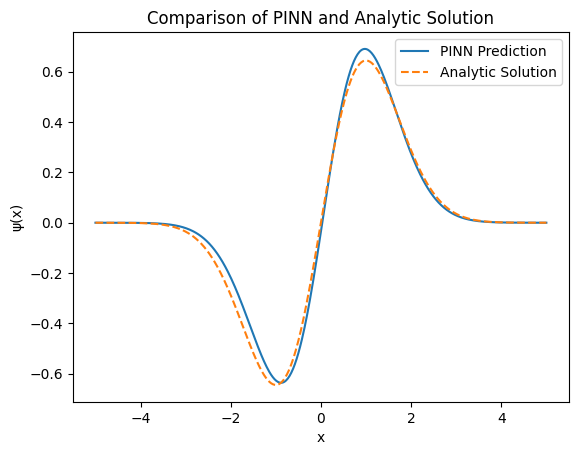

In [16]:
x_test = torch.linspace(x_lim[0], x_lim[1], 512).view(-1, 1).to(device)
compare_analytic(x_test,x_lim,pinn2,n=1)

In [17]:
pinn3 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 5*Loss_Orthogonality([pinn1,pinn2]),
    x_lim=x_lim,
    lr = 1e-3,
    lr_energy=1e-1,
    E_init=1.5,
    width = 8,
    hidden_layers=2,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=5.000e+00. Current loss=5.000e+00. E=0.498495
Epoch 200/3000. Best loss=5.000e+00. Current loss=5.000e+00. E=0.498645
Epoch 300/3000. Best loss=5.000e+00. Current loss=5.000e+00. E=0.498613
Epoch 400/3000. Best loss=5.000e+00. Current loss=5.000e+00. E=0.498593
Epoch 500/3000. Best loss=5.000e+00. Current loss=5.000e+00. E=0.498647
Epoch 600/3000. Best loss=4.999e+00. Current loss=4.999e+00. E=0.498863
Epoch 700/3000. Best loss=4.999e+00. Current loss=4.999e+00. E=0.499434
Epoch 800/3000. Best loss=4.998e+00. Current loss=4.998e+00. E=0.500851
Epoch 900/3000. Best loss=4.997e+00. Current loss=4.997e+00. E=0.505275
Epoch 1000/3000. Best loss=3.282e-01. Current loss=1.487e+00. E=3.341353
Epoch 1100/3000. Best loss=1.579e-01. Current loss=1.579e-01. E=2.589985
Epoch 1200/3000. Best loss=9.871e-02. Current loss=9.871e-02. E=2.561828
Epoch 1300/3000. Best loss=6.710e-02. Current loss=6.710e-02. E=2.545867
Epoch 1400/3000. Best loss=5.192e-02. Current loss=9.528e-02

Predicted Energy: 2.515028, Exact Energy: 2.500000, Relative Error: 0.601130%


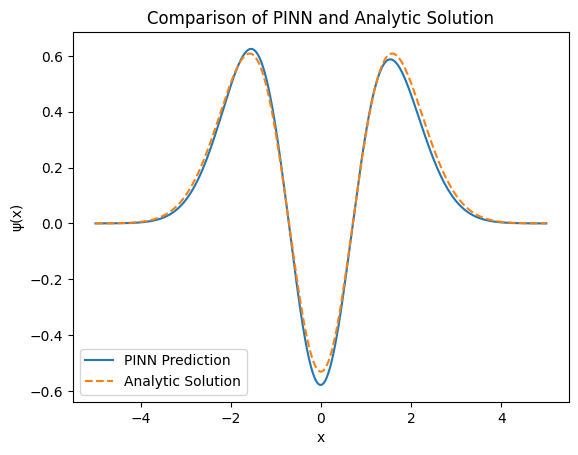

In [18]:
x_test = torch.linspace(x_lim[0], x_lim[1], 512).view(-1, 1).to(device)
compare_analytic(x_test,x_lim,pinn3,n=2)